In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

In [9]:
widthS = 40
widthF = 1
widthP = 40

X, Y = widthS+widthF+widthP+widthF+widthS, 200
lattice = Lattice(X, Y)

t = 1

muS = 1.2 * t
muP = 1.8 * t
muF = 1.4 * t

mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:widthS + widthF] = muF
mu[widthS + widthF:widthS + widthF + widthP] = muP
mu[widthS + widthF + widthP:widthS + widthF + widthP + widthF] = muF
mu[widthS + widthF + widthP + widthF:widthS + widthF + widthP + widthF + widthS] = muS

h0 = 0.9 * t
h = np.zeros_like(mu)
h[widthS:widthS + widthF] = h0
h[widthS + widthF + widthP + widthF-1] = -h0

V = None

U0 = 1.5 * t
U = U0 * np.ones(lattice.X)
U[widthS:-widthS] = 0
U[widthS-1] = U0/2
U[-widthS] = U0/2

V_prime0 = 1.5 * t
V_prime = V_prime0 * np.ones(lattice.X)
V_prime[:widthF+widthS] = 0
V_prime[widthF+widthS+widthP:] = 0
V_prime[widthF+widthS] = V_prime0/2
V_prime[widthF+widthS+widthP-1] = V_prime0/2

T = 0.04

H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
            F0_init=0.12,
            Fuu_init=[0.01, -0.01, 0.01j, -0.01j],
            Fdd_init=[0.01, -0.01, 0.01j, -0.01j],
            hx=h)


In [ ]:
bdg_sc(H, temperature=T,
           atol=1e-3, rtol=1e-1, maxiter=500, 
           verbose=True)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 0.28019076213055816
Relative error: 21769744346.38385
Average old: (0.07868852459016396+0j)
Average: (0.05958601391323952+0j)
F_xplus:
Absolute error: 0.15243186931344013
Relative error: 152431869313.44012
Average old: 0j
Average: (-0.011283360358469217+0j)
F_xmin:
Absolute error: 0.1524331096056071
Relative error: 152433109605.6071
Average old: 0j
Average: (-0.011283552333193137+0j)
F_yplus:
Absolute error: 0.16081903747773385
Relative error: 160819037477.73386
Average old: 0j
Average: (-0.012035795926134312-2.214391910573111e-06j)
F_ymin:
Absolute error: 0.16081903747773385
Relative error: 160819037477.73386
Average old: 0j
Average: (-0.012035795926134312+2.214391910573111e-06j)
Fuu_xplus:
Absolute error: 0.019025073610790016
Relative error: 18043190364.06158
Average old: (0.0033057851239669425+0j)
Average: (0.004010858452317859+0j)
Fuu_xmin:
Absolute error: 0.0190241738436297
Relative error: 18042022906.73498
Average old: (-0.0033057851239669425+0j)
Average: (-0.

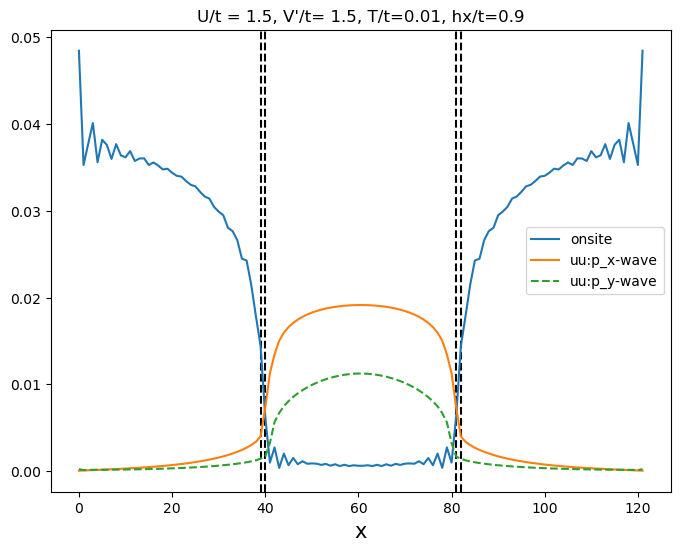

In [ ]:
x = np.arange(0, widthS + widthF + widthP+ widthF + widthS)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"U/t = {U0}, V'/t= {V_prime0}, T/t={T}, hx/t={h0}")
axs.axvline(widthS, color='black', linestyle='--')
axs.axvline(widthS-1, color='black', linestyle='--')
# axs.axvline(widthD+widthF, color='black', linestyle='--')
axs.axvline(widthS + widthF + widthP, color='black', linestyle='--')
axs.axvline(widthS + widthF + widthP+1, color='black', linestyle='--')
# axs.axvline(widthD + widthF + widthP+ widthF-1, color='black', linestyle='--')
axs.plot(x, np.abs(H.F0), label="onsite")
# axs.plot(x, np.abs(F.dwave), label="F.dwave")
# axs.plot(x, np.abs(F.swave), label="F.swave")
# axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
# axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.plot(x, np.abs(Fuu.px - Fdd.px)/2, label="uu:p_x-wave")
axs.plot(x, np.abs(Fuu.py + Fdd.py)/2, "--", label="uu:p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.axhline(np.abs(Fuu.px)[20])
# axs.text(2, (np.abs(Fuu.px))[20]+0.01, f"{(np.abs(Fuu.px))[20]:.6f}")
axs.legend()
plt.show()

In [5]:
print(Fuu.px[25])
print(Fuu.py[25])


(0.0010222209852832032-4.583197451356637e-09j)
(4.849650151704704e-09+0.0004185005026369858j)


In [6]:
# energies = np.linspace(-3,3,1000) 
# dos_values = H.dos(energies, eta=0.005)

# plt.figure(figsize=(5,5))
# plt.plot(energies, dos_values)
# plt.ylim(0, None)
# plt.xlim(-3,3)
# plt.xlabel(r'Energy ($E/t$)', fontsize=16)
# plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)
# plt.show()

In [7]:
temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.10 + 1e-12, 0.01),
    np.arange(0.110, 0.300 + 1e-12, 0.001),
])  # 210 temps total

temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.10 + 1e-12, 0.01),
    np.arange(0.11, 0.30 + 1e-12, 0.01),
    np.arange(0.301, 0.450 + 1e-12, 0.001),
    np.arange(0.460, 0.500 + 1e-12, 0.01),
])  # 194 temps total

temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.35 + 1e-12, 0.01),
    np.arange(0.355, 0.450 + 1e-12, 0.005),
    np.arange(0.451, 0.550 + 1e-12, 0.001),
    np.arange(0.555, 0.600 + 1e-12, 0.005),
])  # 174 temps total

temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.550 + 1e-12, 0.01),
    np.arange(0.555, 0.600 + 1e-12, 0.005),
    np.arange(0.601, 0.700 + 1e-12, 0.001),
    np.arange(0.705, 0.750 + 1e-12, 0.005),
])  # 184 temps total

print(len(temps))



184


In [8]:
V_arr = np.array([
    1,2,3,4,5,
    5.5,6,6.5,7,
    7.5,8,8.5,9,9.5
])

dwave_arr = np.array([
    0.07912, 0.12194, 0.143596, 0.156518, 0.16489,
    0.2, 0.225, 0.25, 0.275,
    0.3, 0.325, 0.35, 0.375, 0.4
])

temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.550 + 1e-12, 0.01),
    np.arange(0.555, 0.600 + 1e-12, 0.005),
    np.arange(0.601, 0.700 + 1e-12, 0.001),
    np.arange(0.705, 0.750 + 1e-12, 0.005),
])  # 184 temps total

print(len(temps) * len(dwave_arr))

2576
